# Clase Nº 4

**Plan de la clase:**  
**(1)** Preguntas sobre la clase asincrónica - Revisar el cuestionario. <br>
**(2)** Comentarios sobre la modalidad de entrega del TP4. <br>
**(3)** Repasar `pandas` y `seaborn` (y widgets) <br>
**(4)** Repasar expresiones regulares (y widgets) <br>
~~**(5)** _Fuzzy matching_~~ (lo dejamos para la siguiente clase)

### Preguntas sobre la clase asincrónica / cuestionario

**Ayudamemoria**: <br>
`\d`: match cuando el string contiene digitos (equivalente a [0-9]) <br>
`\D`: match cuando el string NO contiene digitos <br>
`\s`: match cuando el string contiene un espacio en blanco <br>
`\S`: match cuando el string NO contiene un espacio en blanco <br>
`\w`: match cuando el string contiene caracteres de alfanuméricos o "\_" <br>
`\W`: match cuando el string NO contiene caracteres de alfanuméricos o "\_" <br>

Revisemos la pregunta 3 del cuestionario:

3) Escribir una expresión regular que matchee con:

a.  un string que _contiene_ una letra `a` seguida de cualesquiera  caracteres, y termina en una letra `b`.

In [137]:
import re

In [138]:
string = "12ab091a00abaaba---b"

In [139]:
varias_regex = [
  "a.*b", # correcto
  "a.+b", # correcto, si interpretan que debe haber 1 o más "cualesquiera caracteres", esta sería la expresión regular correcta.
  "a.*?b", # el ? permite que re.findall encuentre submatches dentro de un match grande (por defecto devuelve el grande)
  "a.+?b", # ídem arriba, pero no encuentre el primer match, "ab", porque no hay caracteres entre la "a" y la "b
  "a\w*b", # \w sólo tiene en cuenta caracteres alfanuméricos
  "a\w+b", # ídem arriba
  "[a].*[b]", # los corchetes alrededor de un solo caracter no son necesarios  
]

for regex in varias_regex:
    print(f"{regex}: {re.findall(regex, string)}")

a.*b: ['ab091a00abaaba---b']
a.+b: ['ab091a00abaaba---b']
a.*?b: ['ab', 'a00ab', 'aab', 'a---b']
a.+?b: ['ab091a00ab', 'aab', 'a---b']
a\w*b: ['ab091a00abaab']
a\w+b: ['ab091a00abaab']
[a].*[b]: ['ab091a00abaaba---b']


b. un string que _contiene_ una o más letras `a` seguidas inmediatamente de cero o más dı́gitos.

In [140]:
regex = "a+\d*"
# regex1 = "a+[0-9]*" # equivalente
# regex2 = "a+[0123456789]*" # otra regex equivalente

In [141]:
algunos_strings = ["asaas0000", "a0000", "aba0000"]

for string in algunos_strings:
    print(re.findall(regex, string))

['a', 'aa']
['a0000']
['a', 'a0000']


___

## Modalidad de entrega del TP Nº4

El próximo TP va a ser entregado nuevamente a través de GitHub, pero en este caso va ser **grupal**.

Un miembro del grupo debe crear un repositorio en GitHub como se hizo en el TP3, y agregar como colaboradores a sus dos compañeros y a los docentes.

Un requisito va ser que cada miembro del grupo haga al menos un commit, con contribuciones sustanciales.
Para esto es importante que tengan configurado su nombre de usuario de `git` con el mismo nombre que el de GitHub, así los podemos identificar fácilmente.

___

## Pandas y Seaborn

### Reformateo de `DataFrame`'s

Sigamos trabajando con el DataFrame de centrales eléctricas.

In [142]:
import pandas as pd

In [143]:
df = pd.read_csv("potencia_instalada_mod.csv", sep="|", encoding="latin1")

In [144]:
df.region.value_counts()

NOROESTE         2740
BUENOS AIRES     2283
CENTRO           1880
CUYO             1809
COMAHUE          1642
GRAN BS.AS.      1532
NORESTE          1374
LITORAL           971
PATAGONICA        958
GENERAC MOVIL     580
(en blanco)        24
Name: region, dtype: int64

In [145]:
df.fuente_generacion.value_counts()

Térmica       11191
Renovable      3186
Hidráulica     1266
Nuclear         150
Name: fuente_generacion, dtype: int64

In [146]:
df.head(2)

,Unnamed: 0,id,periodo,central,agente,agente_descripcion,region,categoria_region,tipo_maquina,fuente_generacion,tecnologia,potencia_instalada_mw,fecha_proceso,lote_id_log,mes,indice_tiempo
0,0,2,01/10/2015 0:00,ABRO,CTBROWNG,C.T. ALMIRANTE BROWN,GRAN BS.AS.,Gba - Litoral - Buenos Aires,DI,Térmica,Motor Diesel,25.0,47:17.9,4,10,2015-10
1,1,3,01/10/2015 0:00,ACAJ,CAPEXSAG,C.T. AGUA DEL CAJON,COMAHUE,Comahue,TG,Térmica,Ciclos Combinados,184.4,47:17.9,4,10,2015-10


1. Primero, calculemos la potencia total instalada en cada región en un período dado, haciendo un `groupby` y usando la función de agregación adecuada.

In [147]:
df_region = df.groupby(["region", "periodo"]).agg({"potencia_instalada_mw": "sum"}).reset_index()

# Pregunta de Franco: 
# para generarnos un DataFrame de una sola columna (en lugar de una Series),
# pasamos una lista con una sola columna:
df_region["potencia_instalada_mw"] # esto devuelve una Series
df_region[["potencia_instalada_mw"]] # esto devuelve un DataFrame

,potencia_instalada_mw
0,558.097
1,5693.320
2,5755.920
3,6426.369
4,7136.353
...,...
446,1964.350
447,1003.600
448,1038.600
449,1221.900


2. Luego, formateemos el `DataFrame` de manera que los nombres de las regiones sean ahora los nombres de nuevas columnas, y el contenido de la celda sea la potencia instalada en esa región en el período correspondiente (dado en filas). <br>
Hay que ir de un formato "largo" a uno "ancho".
Pueden consultar la documentación acerca de reformateo de dataframes aquí: https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html, para ver qué método necesitarían usar.

In [148]:
df_region_pivot = df_region.pivot(index="periodo", columns="region", values="potencia_instalada_mw")
df_region_pivot.drop("(en blanco)", axis=1, inplace=True) # eliminamos una columna indeseada

# Durante la clase me olvidé de agregar el string de formateo!
# Eso hizo que las fechas no se parseen correctamente
df_region_pivot.index = pd.to_datetime(df_region_pivot.index, format="%d/%m/%Y %H:%M")
df_region_pivot.sort_index()
df_region_pivot

region,BUENOS AIRES,CENTRO,COMAHUE,CUYO,GENERAC MOVIL,GRAN BS.AS.,LITORAL,NORESTE,NOROESTE,PATAGONICA
periodo,,,,,,,,,,
2016-01-01,5693.320,2911.284,6279.20,1664.43,558.097,6773.850,3042.430,3054.966,2649.550,1003.60
2017-01-01,5755.920,2911.284,6379.20,1726.43,558.097,6773.450,3048.330,3077.266,2682.580,1038.60
2018-01-01,6426.369,3210.920,6788.40,1761.11,199.536,7363.988,3275.480,3080.866,3374.494,1243.90
2019-01-01,7136.353,3316.539,6848.40,1845.29,NaN,7627.444,3727.480,3064.366,3447.062,1525.95
2020-01-01,14963.738,6286.962,13979.60,3967.46,NaN,15606.696,7467.560,6122.988,7139.020,4129.50
2016-02-01,5716.720,2911.284,6279.20,1664.43,558.097,6773.850,3042.430,3054.966,2651.170,1038.60
2017-02-01,5815.120,2911.284,6449.20,1726.43,558.097,6773.450,3068.830,3432.266,2691.580,1038.60
2018-02-01,6549.953,3210.920,6788.40,1761.11,NaN,7373.444,3447.480,3080.866,3401.472,1243.90
2020-02-01,7638.419,3166.281,6992.93,1988.73,NaN,7803.348,3733.780,3061.494,3569.510,2065.95


3. Escribamos una función que reciba como argumento el `DataFrame` formateado como en el punto anterior y un string que represente una región, y utilicemos `seaborn` para hacer un gráfico de la potencia instalada para esa región. Pueden usar, por ejemplo, el tipo de plot `lineplot` (el argumento `data` de la función debe ser el `DataFrame` formateado). Pueden usar los comandos vistos en matplotlib para formatear un plot de Seaborn.

In [149]:
import seaborn as sns

In [150]:
def plot(df, region):
    sns.lineplot(data=df, x="periodo", y=region)

In [151]:
# Examinemos los valores para una región
df_region_pivot[["BUENOS AIRES"]].sort_index().head()

region,BUENOS AIRES
periodo,
2015-10-01,5530.32
2015-11-01,5550.32
2015-12-01,5578.72
2016-01-01,5693.32
2016-02-01,5716.72


Podemos obtener una lista de las regiones, simplemente obteniendo las columnas del dataframe pivoteado

In [152]:
regiones = df_region_pivot.columns.to_list()
regiones

['BUENOS AIRES',
 'CENTRO',
 'COMAHUE',
 'CUYO',
 'GENERAC MOVIL',
 'GRAN BS.AS.',
 'LITORAL',
 'NORESTE',
 'NOROESTE',
 'PATAGONICA']

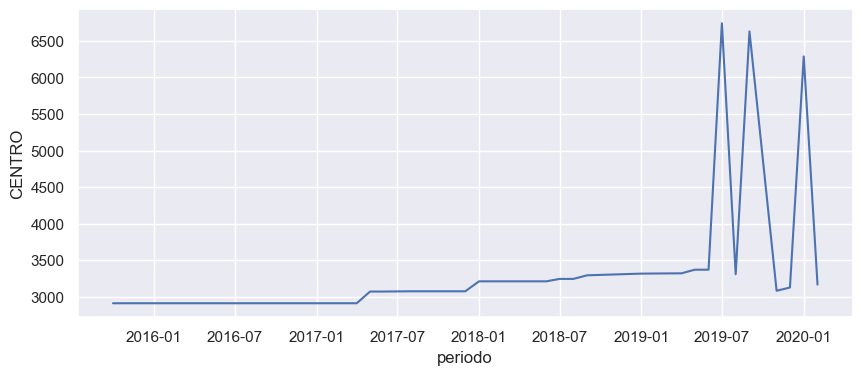

In [153]:
plot(df_region_pivot, "CENTRO")

4. Finalmente, usemos un widget reactivo para elegir qué región graficar. Pueden consultar la documentación de widget acá: https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html.

In [154]:
import ipywidgets as widgets
from ipywidgets import interact

region_w = widgets.Select(options=df_region_pivot.columns)
region_w

Select(options=('BUENOS AIRES', 'CENTRO', 'COMAHUE', 'CUYO', 'GENERAC MOVIL', 'GRAN BS.AS.', 'LITORAL', 'NORES…

Escribimos una función `f` que es una aplicación parcial de la función de arriba, en la cual fijamos uno de los argumentos (el dataframe), de manera que el argumento sea sólo la región. 

Lo pueden pensar similar a lo que ocurre cuando tienen una función de dos variables $f(x,y)$, y definen una nueva al fijar uno de sus argumentos, por ejemplo $g(y)=f(2,y)$ ó $h(x)=f(x,0)$.

In [155]:
# Pueden usar
sns.set(rc={'figure.figsize':(10, 4)})
# para cambiar el tamaño de la figura

def f(region):
    plot(df_region_pivot, region)
    
interact(f, region=region_w);

interactive(children=(Select(description='region', options=('BUENOS AIRES', 'CENTRO', 'COMAHUE', 'CUYO', 'GENE…

La siguiente es otra forma de hacerlo, que usa "decoradores" (esto no lo vimos en clase, pero ahorra un poco de código):

In [156]:
@interact
def f(region=region_w):
    plot(df_region_pivot, region)

interactive(children=(Select(description='region', options=('BUENOS AIRES', 'CENTRO', 'COMAHUE', 'CUYO', 'GENE…

___________________________________________________

## Expresiones regulares

In [157]:
import re

#### Ejercicio:
Vamos a seguir trabajando con el Martín Fierro. <br>
Primero repitamos el proceso de _parseo_ realizado durante la clase asincrónica

In [158]:
with open("martin_fierro.txt", encoding="utf8") as archivo:
    martin_fierro = archivo.read()

In [159]:
def parsear_martin_fierro(martin_fierro):
    partes = re.split("[IVX]+ - .*\n", martin_fierro)
    partes.pop(0)

    estrofas = partes.copy()
    for i in range(len(estrofas)):
        estrofas[i] = re.split("\n\d+\n", estrofas[i])
        estrofas[i].pop(0)

    versos = estrofas.copy()
    for i in range(len(versos)):
        for j in range(len(versos[i])):
            versos[i][j] = versos[i][j].split("\n")
            del versos[i][j][-1]

    versos[-1][-1] = versos[-1][-1][0:6]

    return versos

In [160]:
todos_los_versos = parsear_martin_fierro(martin_fierro)
todos_los_versos[-1][-1]

['Pero ponga su esperanza',
 'en el Dios que lo formó;',
 'y aquí me despido yo',
 'que he relatao a mi modo',
 'MALES QUE CONOCEN TODOS,',
 'PERO QUE NAIDES CONTÓ.']

**Consigna**

Construir un _widget_ reactivo tal que uno pueda escribir una expresión regular y, si tal expresión regular matchea con alguna parte del libro, muestre todos los números de parte, estrofa y verso en los que aparece. Si no aparecen en ningún lado, debe imprimir un mensaje diciendo `"La expresión regular <EXPRESIÓN REGULAR> no matchea con ningún verso del Martín Fierro.`

_Ayudas_: 
- El widget que deberían usar es de tipo `TextArea`. 
- Dentro de la función que se le pasa a `interact` debería haber loops `for` anidados (como se hizo en la clase asincrónica), para iterar sobre las estructuras jerárquicas que componen el libro.
- Recordar, por ejemplo, el método `enumerate` que devuelve tanto los índices como los elementos sobre los cuales se itera (no es estrictamente necesario usarlo, pero puede ser útil).


In [161]:
regex_w = widgets.Textarea()

In [162]:
def encontrar_ocurrencia(patron):

    regex = re.compile(patron)

    no_match = True

    for i, parte in enumerate(todos_los_versos):
        for j, estrofa in enumerate(parte):
            for k, verso in enumerate(estrofa):
                if regex.match(verso):
                    no_match = False
                    print(f"parte {i}, estrofa {j}, verso {k}: {verso}")

    if no_match:
        print(f"La expresión regular {patron} no matchea con ningún verso del Martín Fierro.")

In [ ]:
interact(encontrar_ocurrencia, patron=regex_w);

_______________________________________________________________

## _Fuzzy matching_ (esto lo veremos la próxima clase)

_Fuzzy matching_ refiere al concepto de encontrar correspondencias entre strings que no son exactamente iguales.

Instalemos el módulo `fuzzywuzzy` con `pip install fuzzywuzzy`.

In [1]:
from fuzzywuzzy import fuzz, process

c:\Users\Juani\miniconda3\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


### Distancia de Levenshtein

Es la cantidad mínima de caracteres que deben editarse en un string para equipararlo a otro. Una edición puede ser una inserción, una eliminación o una substitución.

`fuzzywuzzy` es una librería de Python que tiene funciones para medir distancias entre `string`'s. Estima la distancia y devuelve un indicador de similitud entre 0 (menor similitud) y 100 (máxima similitud).

Documentación (es algo básica): https://github.com/seatgeek/fuzzywuzzy

In [165]:
# Simple Ratio
fuzz.ratio("Energía Termica", "Energía Térmica")

93

In [166]:
# Partial Ratio
fuzz.partial_ratio("Energía Termica", "La Energía Térmica es la más común")

93

In [2]:
# Token set ratio
fuzz.token_sort_ratio("La Energía Térmica es la más común", "La más común es Energía Térmica la")

100

In [3]:
# Token set ratio
fuzz.token_set_ratio("La Energía Térmica es la más común", "La más más común es Energía Térmica la la ")

100

In [4]:
from fuzzywuzzy import process

In [171]:
?process.extractOne

Signature:
process.extractOne(
    query,
    choices,
    processor=<function full_process at 0x00000224B72C1F70>,
    scorer=<function WRatio at 0x00000224B43D9EE0>,
    score_cutoff=0,
)
Docstring:
Find the single best match above a score in a list of choices.

This is a convenience method which returns the single best choice.
See extract() for the full arguments list.

Args:
    query: A string to match against
    choices: A list or dictionary of choices, suitable for use with
        extract().
    processor: Optional function for transforming choices before matching.
        See extract().
    scorer: Scoring function for extract().
    score_cutoff: Optional argument for score threshold. If the best
        match is found, but it is not greater than this number, then
        return None anyway ("not a good enough match").  Defaults to 0.

Returns:
    A tuple containing a single match and its score, if a match
    was found that was above score_cutoff. Otherwise, returns None.


In [172]:
fuentes_validas = ['Térmica','Renovable','Hidráulica','Nuclear']

In [173]:
process.extractOne("Temica", fuentes_validas)

('Térmica', 83)

In [174]:
process.extractOne("Temica", fuentes_validas)[0]

'Térmica'

**Aplicación**: examinemos la tabla de potencia instalada:

In [175]:
df = pd.read_csv("potencia_instalada_con_errores.csv", sep="|", encoding="latin1")

In [176]:
df['fuente_generacion'].value_counts()

Térmica       6833
Tmica         2219
Termica       1815
Renovable     1781
Hidráulica     918
Renovale       784
Renobavle      621
Temica         324
Hidrulica      263
Nuclear        150
Hidráulia       85
Name: fuente_generacion, dtype: int64

In [177]:
def limpiar_fuente(fuente_generacion, fuentes_validas=['Térmica','Renovable','Hidráulica','Nuclear']):
    '''
    Función toma como input un string que identifica una fuente
    de generación eléctrica mal escrita y la reemplaza por la fuente
    válida más parecida.
    '''
            
    fuente_procesada = process.extractOne(fuente_generacion, fuentes_validas)[0]    
    return fuente_procesada

In [178]:
df['fuente_generacion'] = df['fuente_generacion'].apply(limpiar_fuente)

In [179]:
df['fuente_generacion'].value_counts()

Térmica       11191
Renovable      3186
Hidráulica     1266
Nuclear         150
Name: fuente_generacion, dtype: int64